# Author Info
---
Name: **Ejaz-ur-Rehman**\
Business Unit Head | Data Analyst | Crystal Tech (Project of MUZHAB Group)\
Faculty Member-Department of Management Sciences | Al Ghazali University\
MS (Finance), PhD Scholar\
Karachi, Pakistan

![Date](https://img.shields.io/badge/Date-01--August--2026-green?logo=google-calendar)
[![Email](https://img.shields.io/badge/Email-ijazfinance%40gmail.com-blue?logo=gmail)](mailto:ijazfinance@gmail.com)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Ejaz--ur--Rehman-blue?logo=linkedin)](https://www.linkedin.com/in/ejaz-ur-rehman/)
[![GitHub](https://img.shields.io/badge/GitHub-ejazurrehman-black?logo=github)](https://github.com/ejazurrehman)

# Machine Learning and Predictive Analytics for Islamic Banking

## Section-01: Introduction

### 1.1 Background

Machine Learning has become one of the most influential technologies in modern financial services. Islamic banks increasingly rely on data-driven techniques to forecast financial performance, identify growth opportunities, assess operational risks, and support strategic decision-making. Unlike traditional statistical analysis, machine learning algorithms can discover complex relationships among financial indicators and generate predictions from historical data.

The previous notebooks established the foundation for predictive analytics. The first notebook explored the dataset through exploratory data analysis (EDA), while the second notebook transformed the raw data into a cleaner and more informative dataset using feature engineering techniques. This notebook builds upon those results by applying machine learning algorithms to the engineered dataset.

### 1.2 Notebook Objectives

After completing this notebook, students will be able to:
- Understand the workflow of a machine learning project in Islamic banking.
- Convert long-format financial data into a machine learning dataset.
- Prepare predictor and target variables.
- Develop regression models for predicting financial indicators.
- Develop classification models for business decision support.
- Evaluate model performance using appropriate metrics.
- Interpret feature importance and model outputs.
- Compare different machine learning algorithms for Islamic banking applications.

### 1.3 Learning Outcomes

By the end of this notebook, students should be able to:

- Prepare financial datasets for machine learning.
- Differentiate between regression and classification problems.
- Train multiple machine learning models using Scikit-learn.
- Evaluate predictive performance using quantitative metrics.
- Explain the business implications of predictive analytics in Islamic banking.

## Section 02: Import Required Libraries

### 2.1 Purpose

This section imports all Python libraries required throughout the notebook. The libraries support data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [1]:
# ============================================================
# Machine Learning Libraries for Islamic Banking Analytics
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Regression Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 3: Load the Feature Engineered Dataset

### 3.1 Purpose

The previous notebook produced a feature-engineered dataset that serves as the input for predictive analytics. In this notebook, the engineered dataset will be loaded and inspected before further transformation.

In [2]:
# ============================================================
# Load Feature Engineered Dataset
# ============================================================

df = pd.read_csv("Islamic_Banking_Feature_Engineered.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 3.2 Display the First Five Records

In [3]:
df.head()

,Country,Regional Code,Report Type,Time Period,USD Exchange Rate,Indicator Code,Indicator Description,currency,units,Values,Values in USD Millions,Year,Quarter,Month,Month_Name,Year_Quarter,Indicator Category,Frequency,Country_Indicator_Count
0,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,AD06_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,16880.01,218.09,2013,4,10,October,2013-Q4,Other,906,136
1,Bangladesh,SA,Islamic Banking,2013-10-01,77.4,AD07_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,603.10,7.79,2013,4,10,October,2013-Q4,Other,906,136
2,Bangladesh,SA,Islamic Banking Windows,2013-10-01,77.4,AD06_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,641.62,8.29,2013,4,10,October,2013-Q4,Other,906,136
3,Bangladesh,SA,Islamic Banking Windows,2013-10-01,77.4,AD07_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,1.08,0.01,2013,4,10,October,2013-Q4,Other,906,136
4,Bangladesh,SA,Islamic Banking,2014-01-01,77.4,AD06_010_010_010,"(a) agriculture, forestry, hunting and fishing",NC,M,16880.01,218.09,2014,1,1,January,2014-Q1,Other,906,136


### 3.3 Display Dataset Shape

In [4]:
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 85,839
Columns : 19


### 3.4 Display Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85839 entries, 0 to 85838
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  85839 non-null  object 
 1   Regional Code            85839 non-null  object 
 2   Report Type              85839 non-null  object 
 3   Time Period              85839 non-null  object 
 4   USD Exchange Rate        85839 non-null  float64
 5   Indicator Code           85839 non-null  object 
 6   Indicator Description    85839 non-null  object 
 7   currency                 68648 non-null  object 
 8   units                    70176 non-null  object 
 9   Values                   73846 non-null  float64
 10  Values in USD Millions   73846 non-null  float64
 11  Year                     85839 non-null  int64  
 12  Quarter                  85839 non-null  int64  
 13  Month                    85839 non-null  int64  
 14  Month_Name            

### 3.5 Display Column Names

In [6]:
df.columns.tolist()

['Country',
 'Regional Code',
 'Report Type',
 'Time Period',
 'USD Exchange Rate',
 'Indicator Code',
 'Indicator Description',
 'currency',
 'units',
 'Values',
 'Values in USD Millions',
 'Year',
 'Quarter',
 'Month',
 'Month_Name',
 'Year_Quarter',
 'Indicator Category',
 'Frequency',
 'Country_Indicator_Count']

## Interpretation

At this stage, the dataset is feature engineered but not yet machine learning ready. Each observation represents a single financial indicator reported by a country during a specific reporting period. This structure is known as long format, which is appropriate for storage and exploratory analysis but must be transformed into wide format before predictive modeling.

The next section will therefore reshape the dataset using a pivot operation so that each row corresponds to one country-period observation and each financial indicator becomes a separate predictor variable.

## Section 4: Data Transformation for Machine Learning

### 4.1 Purpose

The feature-engineered dataset currently exists in long format, where each row represents a single financial indicator for a country during a specific reporting period. While this format is suitable for data storage and exploratory analysis, it is not appropriate for most machine learning algorithms.

Machine learning models require a wide-format dataset, where each row represents a unique observation and each financial indicator becomes a separate feature (predictor). Therefore, the first step in predictive analytics is to reshape the dataset using a pivot operation.

The transformation performed in this section will:

- Convert the dataset from long format to wide format.
- Create one row for each country and reporting period.
- Convert financial indicators into independent predictor variables.
- Produce a machine learning-ready dataset for regression and classification.

### 4.2 Understanding the Transformation
Long Format (Current Dataset)
| Country  | Year_Quarter | Indicator Description  | Values |
| -------- | ------------ | ---------------------- | -----: |
| Pakistan | 2024-Q1      | Total Assets           |  8,750 |
| Pakistan | 2024-Q1      | Total Deposits         |  6,540 |
| Pakistan | 2024-Q1      | Return on Assets       |   1.12 |
| Pakistan | 2024-Q1      | Capital Adequacy Ratio |  16.30 |

Each financial indicator is stored in a separate row.

Wide Format (Machine Learning Dataset)
| Country  | Year_Quarter | Total Assets | Total Deposits |  ROA |   CAR |
| -------- | ------------ | -----------: | -------------: | ---: | ----: |
| Pakistan | 2024-Q1      |         8750 |           6540 | 1.12 | 16.30 |

Each row now represents a complete financial profile of a country for a specific reporting period.

This structure is suitable for machine learning because all predictor variables are available within a single observation.

### 4.3 Create the Pivot Table

In [7]:
# ============================================================
# Convert Long Format into Wide Format
# ============================================================

df_ml = df.pivot_table(
    index=[
        "Country",
        "Year",
        "Quarter",
        "Year_Quarter"
    ],
    columns="Indicator Description",
    values="Values",
    aggfunc="first"
).reset_index()

print("Machine learning dataset created successfully.")

Machine learning dataset created successfully.


### 4.4 Inspect the New Dataset

#### 4.4.1 Display First Five Records

In [8]:
df_ml.head()

Indicator Description,Country,Year,Quarter,Year_Quarter,"(a) agriculture, forestry, hunting and fishing",(b) mining and quarrying,(c) manufacturing,"(d) electricity, gas, steam and air-conditioning supply",(e) water supply; sewerage and waste management,(f)construction,...,Total revenues,Value (or percentage) of gross NPF by economic activities,Value (or percentage) of returns by major type of Sharī`ah-compliant contract,Value of Sharī`ah-compliant financing,Value of Sukūk holdings to capital,Value of gross NPF,Value of large exposures,Wakālah,previously; commerce and trade,"previously; other community, social and personal service activities"
0,Bangladesh,2013,4,2013-Q4,16880.01,194.80,389297.47,8701.02,60.00,20297.79,...,150029.60,NaN,NaN,1038880.72,88.56,43616.42,226983.29,1473.96,NaN,NaN
1,Bangladesh,2014,1,2014-Q1,16880.01,194.80,389297.47,8701.02,60.00,20297.79,...,150029.60,NaN,NaN,1038880.72,88.56,43616.42,226983.29,1473.96,NaN,NaN
2,Bangladesh,2014,2,2014-Q2,22809.76,280.04,368410.46,12224.14,142.03,18570.55,...,155566.67,NaN,NaN,1160209.61,108.26,55142.03,342891.90,431.75,NaN,NaN
3,Bangladesh,2014,3,2014-Q3,22809.76,280.04,368410.46,12224.14,142.03,18570.55,...,155566.67,NaN,NaN,1160209.61,108.26,55142.03,342891.90,431.75,NaN,NaN
4,Bangladesh,2014,4,2014-Q4,15388.65,205.80,460889.94,11315.60,334.34,22200.63,...,160739.95,NaN,NaN,1265833.61,114.21,57618.77,387279.23,1479.97,NaN,NaN


#### 4.4.2 Check Dataset Dimensions

In [9]:
print(f"Rows    : {df_ml.shape[0]:,}")
print(f"Columns : {df_ml.shape[1]}")

Rows    : 227
Columns : 143


#### 4.4.3 Check Variable Types

In [10]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Columns: 143 entries, Country to previously; other community, social and personal service activities
dtypes: float64(139), int64(2), object(2)
memory usage: 253.7+ KB


#### 4.4.4 Display Variable Names

In [11]:
df_ml.columns.tolist()

['Country',
 'Year',
 'Quarter',
 'Year_Quarter',
 '(a) agriculture, forestry, hunting and fishing',
 '(b) mining and quarrying',
 '(c) manufacturing',
 '(d) electricity, gas, steam and air-conditioning supply',
 '(e) water supply; sewerage and waste management',
 '(f)construction',
 '(g) wholesale and retail trade; repair of motor vehicles and motorcycles',
 '(h) transportation and storage',
 '(i)',
 '(i)accommodation and food service activities',
 '(ii)',
 '(iii)',
 '(j)information and communication',
 '(k) financial and insurance activities ',
 '(l)real estate activities',
 '(m)  professional, scientific and technical activities',
 '(n) administrative and support service activities',
 '(o) public administration and defense; compulsory social security',
 '(p) education',
 '(q) human health and social work activities',
 '(r)arts, entertainment and recreation',
 '(s) other service activities (export)',
 '(t) activities of households as employers',
 '(t*)    other financing of household

### 4.5 Verify the Transformation

The following checks confirm that the transformation has been performed correctly.

#### 4.5.1 Check for Duplicate Observations

In [12]:
duplicates = df_ml.duplicated().sum()

print(f"Duplicate rows : {duplicates}")

Duplicate rows : 0


#### 4.5.2 Check Missing Values

In [13]:
missing = (
    df_ml
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

Indicator Description
Assets held by domestic systemically important Islamic banks                      199
Value (or percentage) of returns by major type of Sharī`ah-compliant contract     199
(v)   others                                                                      191
(v)     others                                                                    191
Common Equity Tier 1 (CET1) capital to RWA (IFSB)                                 190
                                                                                 ... 
Growth of financing to private sector                                               5
Total financing at end of current period                                            5
Total financing at end of same period in previous year                              5
Liquid assets ratio                                                                 5
Diminishing Mushārakah                                                              2
Length: 74, dtype: int64

#### 4.5.3 Summary Statistics

In [14]:
df_ml.describe().T

,count,mean,std,min,25%,50%,75%,max
Indicator Description,,,,,,,,
Year,227.0,2018.991189,3.400925,2013.00,2016.0000,2019.00,2.022000e+03,2025.00
Quarter,227.0,2.519824,1.126237,1.00,2.0000,3.00,4.000000e+00,4.00
"(a) agriculture, forestry, hunting and fishing",227.0,12082.758018,11315.329952,0.18,2741.9150,9121.57,1.850929e+04,49653.54
(b) mining and quarrying,227.0,3539.264537,5517.248835,0.03,234.2550,2309.72,4.769235e+03,38592.20
(c) manufacturing,227.0,183569.671454,401056.962533,62.47,15086.9250,24334.70,4.163289e+04,2124122.70
...,...,...,...,...,...,...,...,...
Value of gross NPF,206.0,30107.632864,37900.139357,3364.98,7101.9475,8866.63,4.871221e+04,134590.75
Value of large exposures,64.0,898445.410156,602967.077018,226983.29,474024.8525,665095.32,1.145593e+06,2766426.45
Wakālah,156.0,1222.019359,2058.009520,0.00,0.0000,4.22,1.508378e+03,8656.79


### 4.6 Save the Machine Learning Dataset

The transformed dataset will be used throughout the remainder of the notebook.

In [15]:
df_ml.to_csv(
    "Islamic_Banking_ML_Dataset.csv",
    index=False
)

print("Machine learning dataset saved successfully.")

Machine learning dataset saved successfully.


## Interpretation

The dataset has now been transformed into a machine learning-ready structure. Each row represents a unique country during a specific reporting period, while each column represents a financial indicator that can serve as a predictor in subsequent models.

The pivot transformation has introduced missing values because not every country reports every financial indicator in every reporting period. Before developing predictive models, these missing values must be carefully examined and treated. The next section focuses on data preparation for machine learning, including missing value analysis, feature selection, and data quality assessment.

## Section 5: Data Preparation for Machine Learning

### 5.1 Purpose

The machine learning dataset created in the previous section contains one observation for each country and reporting period. However, the transformation from long format to wide format introduced missing values because not every financial indicator is reported by every country during every reporting period.

Before building predictive models, it is essential to evaluate the quality of the transformed dataset. This section focuses on identifying missing values, selecting an appropriate treatment strategy, removing variables with excessive missingness, and verifying that the final dataset is suitable for machine learning.

By the end of this section, the dataset will be fully prepared for feature selection and predictive modeling.

### 5.2 Overview of Missing Values

The first step is to identify variables containing missing observations.

In [16]:
# ============================================================
# Missing Values Summary
# ============================================================

missing_count = (
    df_ml
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_count = missing_count[missing_count > 0]

print(f"Variables with missing values: {len(missing_count)}")

missing_count

Variables with missing values: 74


Indicator Description
Assets held by domestic systemically important Islamic banks                      199
Value (or percentage) of returns by major type of Sharī`ah-compliant contract     199
(v)   others                                                                      191
(v)     others                                                                    191
Common Equity Tier 1 (CET1) capital to RWA (IFSB)                                 190
                                                                                 ... 
Growth of financing to private sector                                               5
Total financing at end of current period                                            5
Total financing at end of same period in previous year                              5
Liquid assets ratio                                                                 5
Diminishing Mushārakah                                                              2
Length: 74, dtype: int64

### Interpretation

The output displays the number of missing observations for each variable. These missing values are expected because several financial indicators are reported only by selected countries or during specific reporting periods. Therefore, missing values at this stage do not necessarily indicate data quality issues but rather differences in reporting practices across jurisdictions.

### 5.3 Missing Value Percentage

Absolute counts alone do not fully describe the extent of missingness. Calculating the percentage of missing observations provides a more meaningful basis for deciding whether a variable should be retained, imputed, or removed.

In [17]:
# ============================================================
# Missing Percentage
# ============================================================

missing_percent = (
    df_ml
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent = missing_percent[missing_percent > 0]

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent.round(2)
})

missing_summary

,Missing Count,Missing Percentage
Indicator Description,,
Assets held by domestic systemically important Islamic banks,199,87.67
Value (or percentage) of returns by major type of Sharī`ah-compliant contract,199,87.67
(v) others,191,84.14
(v) others,191,84.14
Common Equity Tier 1 (CET1) capital to RWA (IFSB),190,83.70
...,...,...
Growth of financing to private sector,5,2.20
Total financing at end of current period,5,2.20
Total financing at end of same period in previous year,5,2.20


### 5.4 Visualizing Missing Values

A graphical representation helps identify variables with substantial missingness.

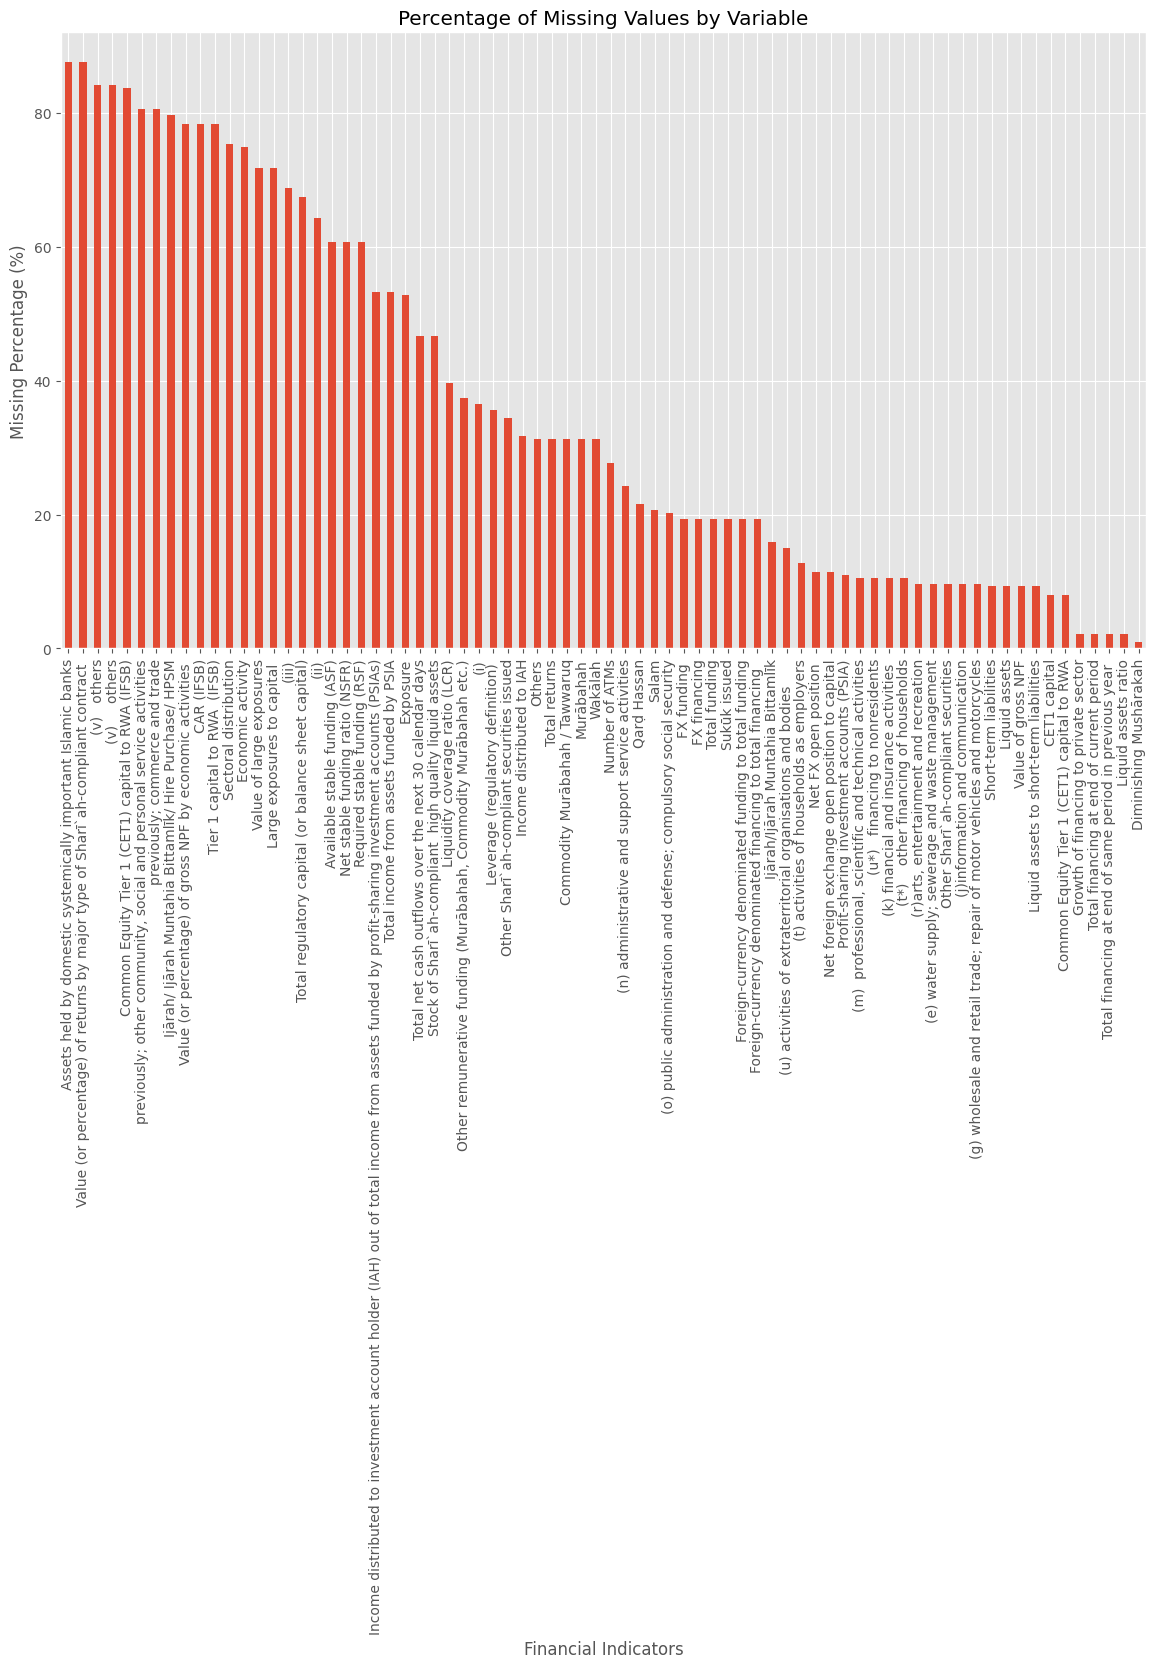

In [18]:
# ============================================================
# Missing Value Percentage
# ============================================================

plt.figure(figsize=(14,8))

missing_summary["Missing Percentage"].plot(kind="bar")

plt.title("Percentage of Missing Values by Variable")
plt.xlabel("Financial Indicators")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### 5.5 Missing Value Treatment Strategy

Before applying any treatment, a clear decision rule is required. The following framework will be used throughout this notebook.
| Missing Percentage | Treatment Strategy                                    |
| -----------------: | ----------------------------------------------------- |
|                 0% | Retain variable                                       |
|       Less than 5% | Median imputation                                     |
|          5% to 30% | Evaluate business importance, then impute if retained |
|         30% to 70% | Retain only if financially significant                |
|   Greater than 70% | Remove from the dataset                               |

**NOTE**: This framework balances statistical quality with the practical relevance of financial indicators.

### 5.6 Remove Variables with Excessive Missing Values

Variables containing more than 70% missing observations contribute limited information and may adversely affect model performance. Such variables will therefore be removed.

In [19]:
# ============================================================
# Remove Variables with High Missingness
# ============================================================

threshold = 70

columns_to_drop = missing_percent[
    missing_percent > threshold
].index

print("Variables to be removed:")
print(columns_to_drop.tolist())

df_ml_clean = df_ml.drop(columns=columns_to_drop)

print(f"\nVariables removed : {len(columns_to_drop)}")
print(f"Remaining columns : {df_ml_clean.shape[1]}")

Variables to be removed:
['Assets held by domestic systemically important Islamic banks', 'Value (or percentage) of returns by major type of Sharī`ah-compliant contract ', '(v)   others', '(v)     others', 'Common Equity Tier 1 (CET1) capital to RWA (IFSB)', 'previously; other community, social and personal service activities', 'previously; commerce and trade', 'Ijārah/ Ijārah Muntahia Bittamlīk/ Hire Purchase/ HPSM', 'Value (or percentage) of gross NPF by economic activities ', 'CAR (IFSB)', 'Tier 1 capital to RWA  (IFSB)', 'Sectoral distribution', 'Economic activity', 'Value of large exposures', 'Large exposures to capital ']

Variables removed : 15
Remaining columns : 128


### 5.7 Impute Remaining Missing Values

After removing variables with excessive missingness, the remaining numerical variables are imputed using the median. Median imputation is appropriate because it is robust to extreme values that are common in financial datasets.

In [20]:
# ============================================================
# Median Imputation
# ============================================================

numeric_columns = df_ml_clean.select_dtypes(include=["number"]).columns

df_ml_clean[numeric_columns] = (
    df_ml_clean[numeric_columns]
    .fillna(df_ml_clean[numeric_columns].median())
)

print("Missing values have been imputed using the median.")

Missing values have been imputed using the median.


### 5.8 Verify Data Quality

The final verification confirms that the dataset is complete and ready for predictive modeling.

In [21]:
# ============================================================
# Final Missing Value Check
# ============================================================

remaining_missing = df_ml_clean.isnull().sum().sum()

print(f"Remaining missing values: {remaining_missing}")

Remaining missing values: 0


#### 5.8.1 Display Dataset Information

In [22]:
df_ml_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Columns: 128 entries, Country to Wakālah
dtypes: float64(124), int64(2), object(2)
memory usage: 227.1+ KB


#### 5.8.2 Display Dataset Shape

In [23]:
print(f"Rows    : {df_ml_clean.shape[0]:,}")
print(f"Columns : {df_ml_clean.shape[1]}")

Rows    : 227
Columns : 128


### 5.9 Save the Clean Machine Learning Dataset

The cleaned dataset will be used throughout the remainder of the notebook.

In [24]:
# ============================================================
# Save Clean Machine Learning Dataset
# ============================================================

df_ml_clean.to_csv(
    "Islamic_Banking_ML_Clean.csv",
    index=False
)

print("Clean machine learning dataset saved successfully.")

Clean machine learning dataset saved successfully.


## Interpretation

The machine learning dataset has now been cleaned and prepared for predictive analytics. Variables with excessive missing values were removed, while the remaining numerical variables were completed using median imputation. These preprocessing steps improve data quality and ensure that machine learning algorithms can be trained without interruptions caused by incomplete observations.

The resulting dataset provides a reliable foundation for model development while preserving the most informative financial indicators.

## Section 6: Feature Selection and Target Variable Identification

### 6.1 Purpose

Feature selection is a critical step in the machine learning pipeline. Although the cleaned dataset contains numerous financial indicators, not every variable should be included in predictive modeling. Some variables serve only as identifiers, while others may introduce redundancy or target leakage, leading to overly optimistic model performance.

This section aims to identify informative predictor variables and establish suitable target variables for both regression and classification. The resulting feature set will provide a reliable foundation for developing predictive models in the following sections.

### 6.2 Understanding Predictor and Target Variables

In supervised machine learning, the dataset is divided into two components:

- Predictor variables (X): Independent variables used by the model to learn patterns.
- Target variable (y): The outcome that the model attempts to predict.

For this notebook:

- Regression: Predict a continuous financial indicator.
- Classification: Predict a categorical banking class derived from financial data.

### 6.3 Review Available Variables

Before selecting predictors, review the variables available in the cleaned dataset.

In [25]:
# ============================================================
# Review Variables
# ============================================================

print(f"Total Variables : {len(df_ml_clean.columns)}")

for column in df_ml_clean.columns:
    print(column)

Total Variables : 128
Country
Year
Quarter
Year_Quarter
(a) agriculture, forestry, hunting and fishing
(b) mining and quarrying
(c) manufacturing
(d) electricity, gas, steam and air-conditioning supply
(e) water supply; sewerage and waste management
(f)construction
(g) wholesale and retail trade; repair of motor vehicles and motorcycles
(h) transportation and storage
(i)
(i)accommodation and food service activities
(ii)
(iii)
(j)information and communication
(k) financial and insurance activities 
(l)real estate activities
(m)  professional, scientific and technical activities
(n) administrative and support service activities
(o) public administration and defense; compulsory social security
(p) education
(q) human health and social work activities
(r)arts, entertainment and recreation
(s) other service activities (export)
(t) activities of households as employers
(t*)    other financing of households
(u) activities of extraterritorial organisations and bodies      
(u*)   financing to 

### 6.4 Remove Identifier Variables

Several variables uniquely identify an observation but contain no predictive information. These variables should not be used as model inputs.

In [26]:
# ============================================================
# Identifier Variables
# ============================================================

identifier_columns = [
    "Country",
    "Year",
    "Quarter",
    "Year_Quarter"
]

df_model = df_ml_clean.copy()

print("Identifier variables identified.")
print(identifier_columns)

Identifier variables identified.
['Country', 'Year', 'Quarter', 'Year_Quarter']


> Note: These variables will remain in the dataset for reporting and interpretation but will be excluded from the feature matrix (X).

### 6.5 Detect Highly Correlated Variables

Highly correlated variables may provide duplicate information and increase multicollinearity, particularly in regression models.

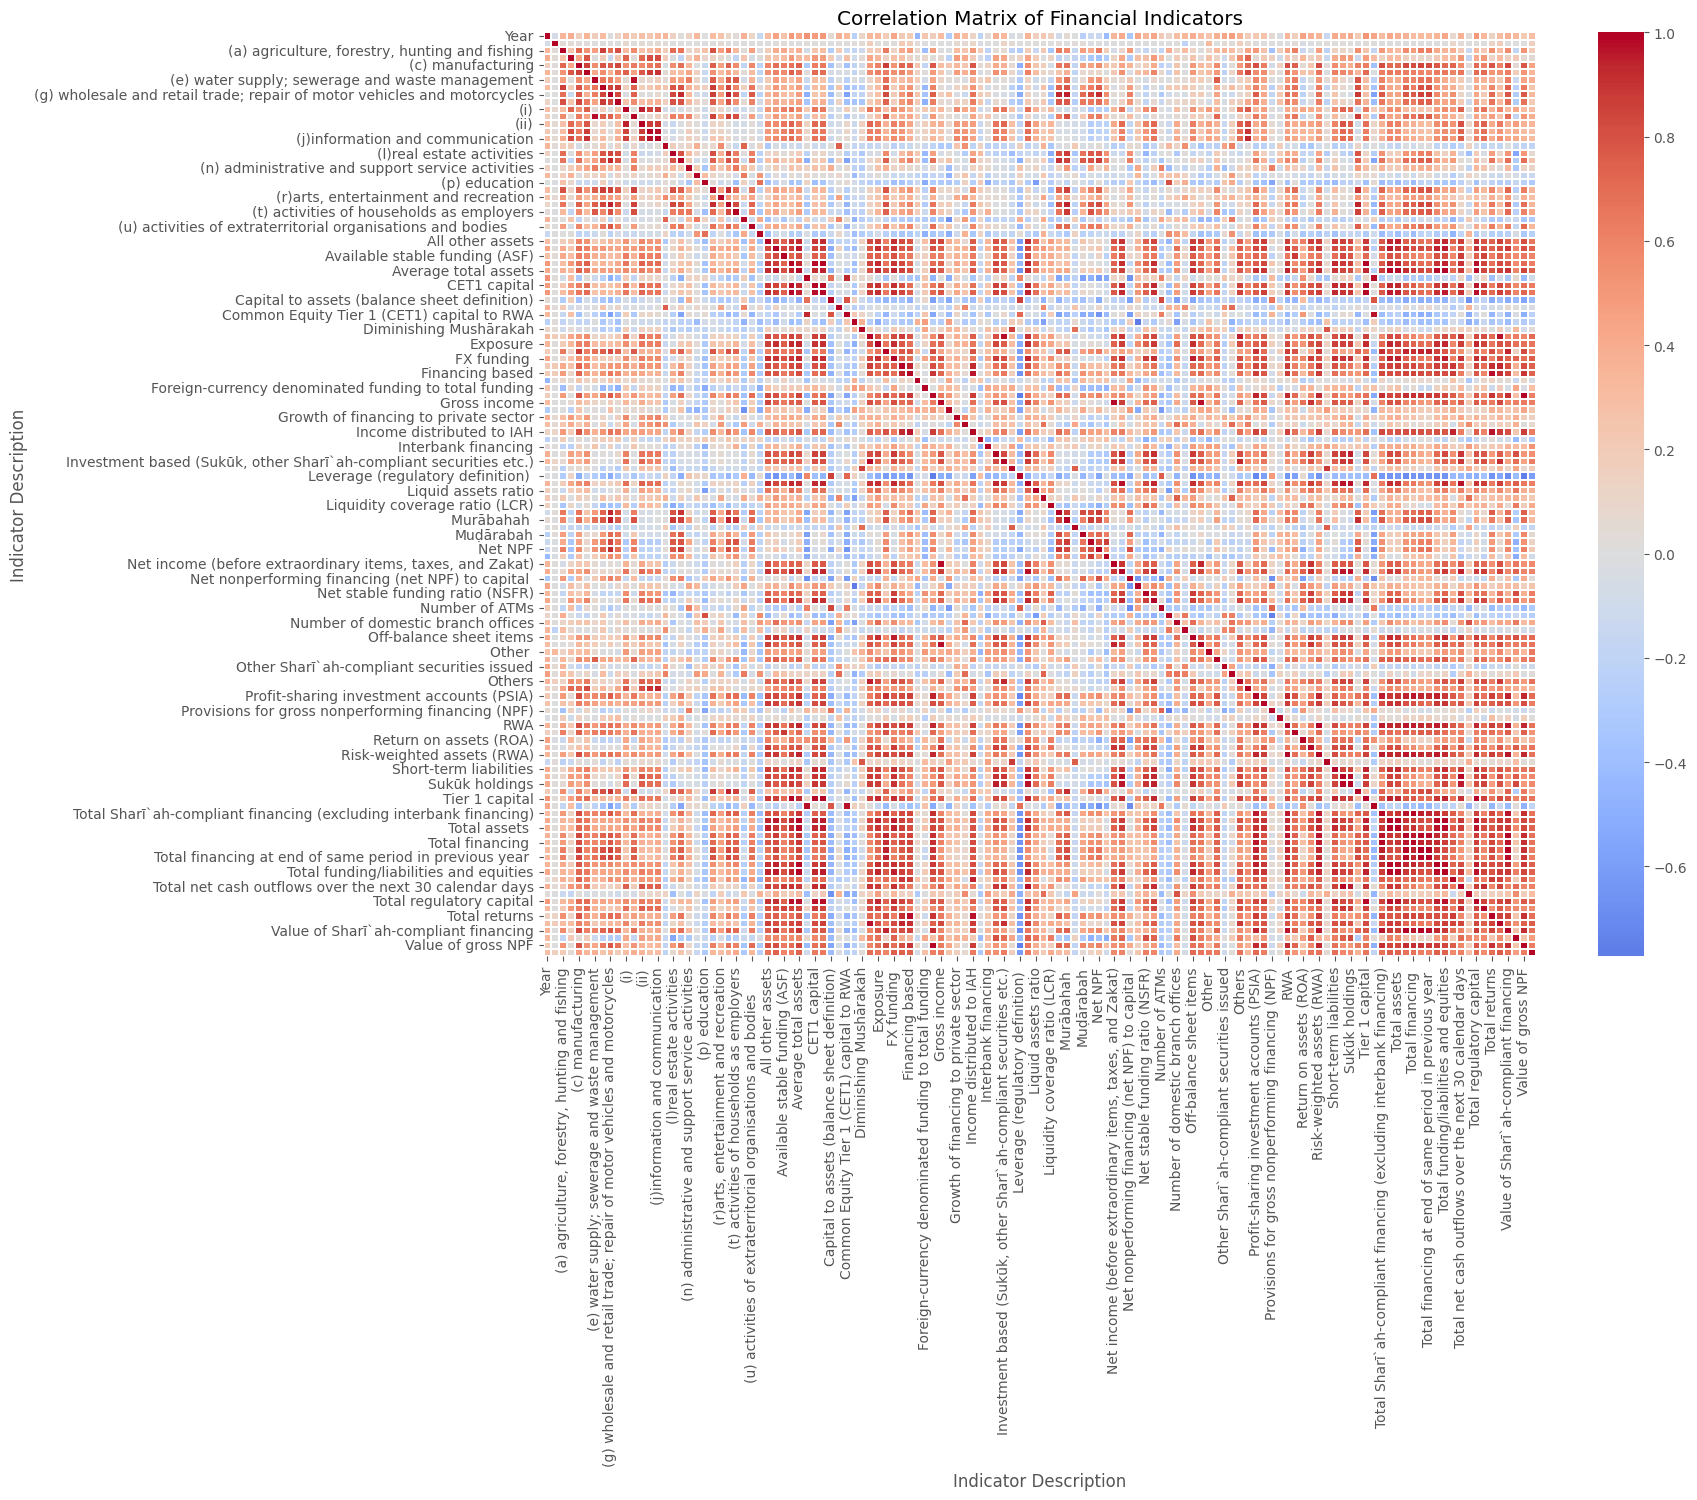

In [27]:
# ============================================================
# Correlation Matrix
# ============================================================

numeric_df = df_model.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Matrix of Financial Indicators")
plt.show()

### 6.6 Identify Highly Correlated Pairs

To simplify interpretation, identify variable pairs with an absolute correlation greater than 0.90.

In [30]:
print(df_model.columns.name)

Indicator Description


In [31]:
# Remove the column index name left by pivot_table()
df_model.columns.name = None

In [32]:
# ============================================================
# Highly Correlated Variable Pairs
# ============================================================

# Remove the column index name if it exists
correlation_matrix.columns.name = None
correlation_matrix.index.name = None

high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        corr = correlation_matrix.iloc[i, j]

        if abs(corr) >= 0.90:
            high_corr_pairs.append([
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                round(corr, 3)
            ])

high_corr = pd.DataFrame(
    high_corr_pairs,
    columns=[
        "Variable 1",
        "Variable 2",
        "Correlation"
    ]
)

high_corr = high_corr.sort_values(
    by="Correlation",
    ascending=False
)

high_corr.head(20)

,Variable 1,Variable 2,Correlation
181,RWA,Risk-weighted assets (RWA),1.000
237,Total financing,Value of Sharī`ah-compliant financing,1.000
227,Total assets,Total funding/liabilities and equities,1.000
219,Total Sharī`ah-compliant financing (excluding ...,Total financing,0.999
53,Average total assets,Total assets,0.998
57,Average total assets,Total funding/liabilities and equities,0.998
32,Average equity,Capital and reserves,0.992
244,Total financing at end of current period,Total financing at end of same period in previ...,0.992
38,Average equity,Tier 1 capital,0.990
81,Capital and reserves,Tier 1 capital,0.989


### Interpretation

A high correlation between two predictors indicates that they contain similar information. During model development, only one of the variables may be retained to reduce redundancy and improve interpretability. However, removal should also consider financial relevance rather than relying solely on statistical thresholds.

### 6.7 Data Integrity Check

#### 6.7.1 Identify Duplicate Columns

In [43]:
# ============================================================
# Identify Duplicate Column Names
# ============================================================

duplicate_columns = df_model.columns[df_model.columns.duplicated()]

print(f"Duplicate columns found: {len(duplicate_columns)}")
print(duplicate_columns.tolist())

Duplicate columns found: 4
['Murābahah', 'Others', 'Total assets', 'Total financing']


#### 6.6.2 Investigate Duplicate Columns

Before removing them, compare whether the duplicate columns contain identical values.

In [44]:
# ============================================================
# Compare Duplicate Columns
# ============================================================

duplicates = duplicate_columns.unique()

for col in duplicates:

    duplicate_df = df_model.loc[:, df_model.columns == col]

    print(f"\nColumn: {col}")
    print(f"Occurrences: {duplicate_df.shape[1]}")

    if duplicate_df.shape[1] == 2:
        identical = duplicate_df.iloc[:, 0].equals(duplicate_df.iloc[:, 1])
        print(f"Identical values: {identical}")


Column: Murābahah
Occurrences: 2
Identical values: False

Column: Others
Occurrences: 2
Identical values: False

Column: Total assets
Occurrences: 2
Identical values: False

Column: Total financing
Occurrences: 2
Identical values: False


#### 6.7.3 Remove Duplicate Columns

If the duplicates are confirmed to be identical, retain the first occurrence.

In [45]:
# ============================================================
# Remove Duplicate Columns
# ============================================================

df_model = df_model.loc[:, ~df_model.columns.duplicated()]

print("Duplicate columns removed.")
print(f"Remaining variables: {df_model.shape[1]}")

Duplicate columns removed.
Remaining variables: 124


#### 6.7.4 Verify Data Integrity

In [46]:
duplicate_columns = df_model.columns[df_model.columns.duplicated()]

print("Remaining duplicate columns:")
print(duplicate_columns.tolist())

Remaining duplicate columns:
[]


### 6.7 Selection of Target Variables
Purpose

The objective of supervised machine learning is to predict an outcome variable using a set of explanatory variables. Therefore, selecting an appropriate target variable is one of the most important decisions in model development.

This notebook demonstrates both regression and classification using the same Islamic banking dataset. Consequently, two target variables will be prepared:

- A continuous target for regression.
- A categorical target for classification.

Before selecting these targets, it is important to avoid target leakage, where predictor variables contain direct information about the target variable, resulting in unrealistically high prediction accuracy.

#### 6.7.1 Define the Regression Target

Following the data integrity checks, Total assets is selected as the regression target because it is a continuous financial indicator that reflects the overall size of the Islamic banking sector and is widely used in banking analysis.

In [47]:
# ============================================================
# Define Regression Target
# ============================================================

target_regression = "Total assets"

print("Regression Target:")
print(target_regression)

Regression Target:
Total assets


#### 6.7.2 Verify Target Availability

Before continuing, verify that the selected target variable exists in the dataset.

In [48]:
# ============================================================
# Verify Target Variable
# ============================================================

if target_regression in df_model.columns:
    print(f"'{target_regression}' found successfully.")
else:
    raise ValueError(f"Target variable '{target_regression}' was not found.")

'Total assets' found successfully.


#### 6.7.3 Create the Classification Target

To demonstrate classification algorithms, a binary target variable is created using the median value of Total assets. Observations above the median are classified as High Asset Banks, while those below the median are classified as Low Asset Banks.

In [49]:
# ============================================================
# Create Classification Target
# ============================================================

median_assets = df_model[target_regression].median()

df_model["High_Asset_Bank"] = np.where(
    df_model[target_regression] >= median_assets,
    1,
    0
)

print("Classification target created successfully.")

Classification target created successfully.


#### 6.7.4 Examine Class Distribution

An approximately balanced class distribution improves the performance of many classification algorithms.

In [50]:
# ============================================================
# Class Distribution
# ============================================================

class_distribution = (
    df_model["High_Asset_Bank"]
    .value_counts()
    .sort_index()
)

print(class_distribution)

High_Asset_Bank
0    113
1    114
Name: count, dtype: int64


##### 6.7.4.1 Visualize the Class Distribution

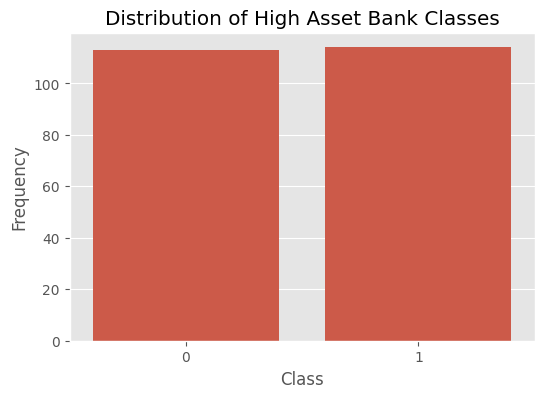

In [51]:
# ============================================================
# Visualize Target Classes
# ============================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="High_Asset_Bank",
    data=df_model
)

plt.title("Distribution of High Asset Bank Classes")
plt.xlabel("Class")
plt.ylabel("Frequency")

plt.show()

#### 6.7.5 Summary of Target Variables
| Machine Learning Task | Target Variable | Data Type  |
| --------------------- | --------------- | ---------- |
| Regression            | Total assets    | Continuous |
| Classification        | High_Asset_Bank | Binary     |


### Interpretation

The dataset now contains two target variables suitable for supervised machine learning. The continuous variable Total assets will be used to develop regression models, while the derived High_Asset_Bank variable will support binary classification. Both targets are based on the same underlying financial indicator, allowing students to compare regression and classification techniques using a common dataset.

## Section 7: Regression Modeling

### 7.1 Purpose

Regression analysis is one of the most widely used supervised machine learning techniques for predicting continuous numerical variables. In Islamic banking, regression models can support forecasting, strategic planning, financial performance evaluation, and regulatory analysis.

In this section, multiple regression algorithms will be developed to predict Total assets using the engineered financial indicators prepared in the previous sections. The performance of each model will then be evaluated and compared using standard regression metrics.

### 7.2 Prepare the Feature Matrix and Target Variable

The first step is to separate the predictor variables (X) from the regression target (y).

Identifier variables are excluded because they uniquely identify observations but do not contribute to prediction.

Similarly, the classification target created in Section 6 is removed to prevent information leakage.

In [52]:
# ============================================================
# Prepare Features and Target
# ============================================================

identifier_columns = [
    "Country",
    "Year",
    "Quarter",
    "Year_Quarter"
]

target_regression = "Total assets"

X = df_model.drop(
    columns=identifier_columns +
            [target_regression,
             "High_Asset_Bank"],
    errors="ignore"
)

y = df_model[target_regression]

print(f"Predictor Variables : {X.shape[1]}")
print(f"Observations        : {X.shape[0]}")

Predictor Variables : 119
Observations        : 227


### 7.3 Train-Test Split

To evaluate predictive performance objectively, the dataset is divided into training and testing subsets. The training data are used to build the regression model, while the testing data provide an unbiased assessment of model performance.

An 80:20 split is adopted, which is commonly used in machine learning applications.

In [53]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training observations : {X_train.shape[0]}")
print(f"Testing observations  : {X_test.shape[0]}")

Training observations : 181
Testing observations  : 46


### 7.4 Feature Scaling

Many machine learning algorithms perform better when numerical variables are measured on comparable scales. Standardization transforms each feature to have a mean of zero and a standard deviation of one.

Although tree-based algorithms do not require scaling, it is beneficial for algorithms such as Linear Regression and will also support the classification models developed later in this notebook.

In [54]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### 7.5 Baseline Model: Linear Regression

Linear Regression provides a simple and interpretable benchmark for predicting continuous variables. More advanced models will later be compared against this baseline.

In [55]:
# ============================================================
# Linear Regression
# ============================================================

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 7.6 Model Evaluation

The predictive performance of the regression model is evaluated using three widely accepted metrics.

- MAE (Mean Absolute Error): Average prediction error.
- RMSE (Root Mean Squared Error): Penalizes larger prediction errors.
- R² Score: Measures the proportion of variation explained by the model.

In [56]:
# ============================================================
# Evaluate Linear Regression
# ============================================================

mae = mean_absolute_error(y_test, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [mae, rmse, r2]
})

results

,Metric,Value
0,MAE,4828.468984
1,RMSE,12388.631128
2,R² Score,0.999944


### 7.7 Predicted vs Actual Values

A visual comparison between observed and predicted values provides insight into model performance.

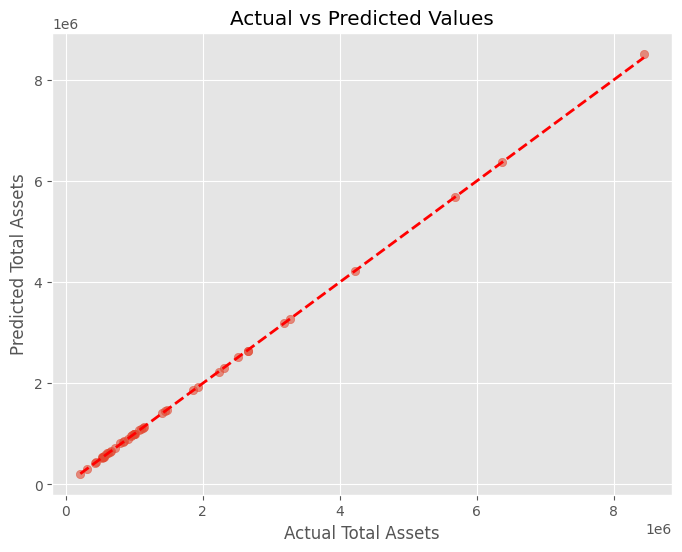

In [57]:
# ============================================================
# Predicted vs Actual Values
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Total Assets")
plt.ylabel("Predicted Total Assets")
plt.title("Actual vs Predicted Values")

plt.show()

### 7.8 Residual Analysis

Residuals represent the prediction errors made by the regression model. Examining their distribution helps determine whether the model systematically overestimates or underestimates the target variable.

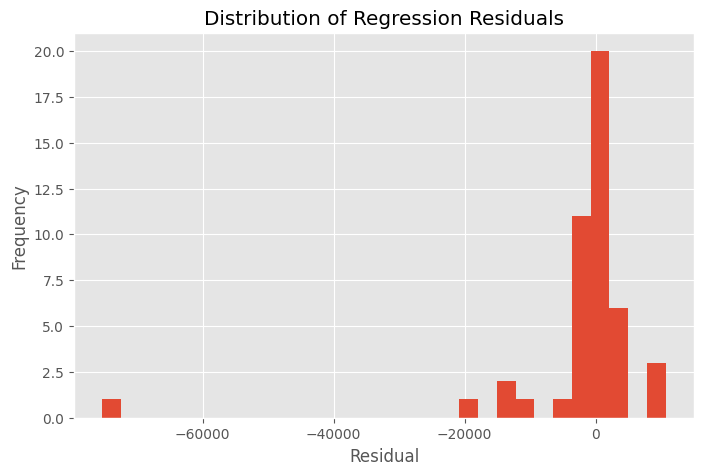

In [58]:
# ============================================================
# Residual Analysis
# ============================================================

residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The Linear Regression model serves as the benchmark for predicting Total assets. The evaluation metrics quantify predictive accuracy, while the scatter plot and residual analysis provide a visual assessment of model performance.

These results establish a baseline against which more sophisticated machine learning algorithms will be compared.

## Section 8: Advanced Regression Models and Model Comparison

### 8.1 Purpose

Linear Regression provides a useful baseline model, but financial data frequently exhibit nonlinear relationships that cannot be adequately captured using linear methods. Ensemble learning algorithms are capable of modelling complex interactions among financial indicators and often produce more accurate predictions.

This section develops three advanced regression models and compares their performance with the baseline Linear Regression model. The objective is to identify the model that provides the most accurate prediction of Total assets.

### 8.2 Decision Tree Regression

Decision Trees partition the predictor space into a series of decision rules. They are easy to interpret and can model nonlinear relationships without requiring feature scaling.

In [59]:
# ============================================================
# Decision Tree Regression
# ============================================================

dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


#### 8.2.1 Evaluate Decision Tree

In [60]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)

dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

dt_r2 = r2_score(y_test, y_pred_dt)

### 8.3 Random Forest Regression

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is one of the most widely used machine learning algorithms in financial analytics.

In [61]:
# ============================================================
# Random Forest Regression
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


#### 8.3.1 Evaluate Random Forest

In [62]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

rf_r2 = r2_score(y_test, y_pred_rf)

### 8.4 Gradient Boosting Regression

Gradient Boosting builds models sequentially, where each new tree attempts to correct the prediction errors of previous trees.

In [63]:
# ============================================================
# Gradient Boosting Regression
# ============================================================

gb_model = GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


#### 8.4.1 Evaluate Gradient Boosting

In [64]:
gb_mae = mean_absolute_error(y_test, y_pred_gb)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

gb_r2 = r2_score(y_test, y_pred_gb)

### 8.5 Compare All Regression Models

The performance of the four regression models is summarized using three evaluation metrics.

In [65]:
# ============================================================
# Regression Model Comparison
# ============================================================

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE":[
        rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R²":[
        r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]

})

comparison.sort_values(
    by="R²",
    ascending=False
)

,Model,MAE,RMSE,R²
0,Linear Regression,4828.468984,12388.631128,0.999944
3,Gradient Boosting,35929.380144,124816.094738,0.994343
1,Decision Tree,67069.547500,143246.184658,0.992548
2,Random Forest,48733.441466,196569.470372,0.985968


### 8.6 Visual Comparison of Models

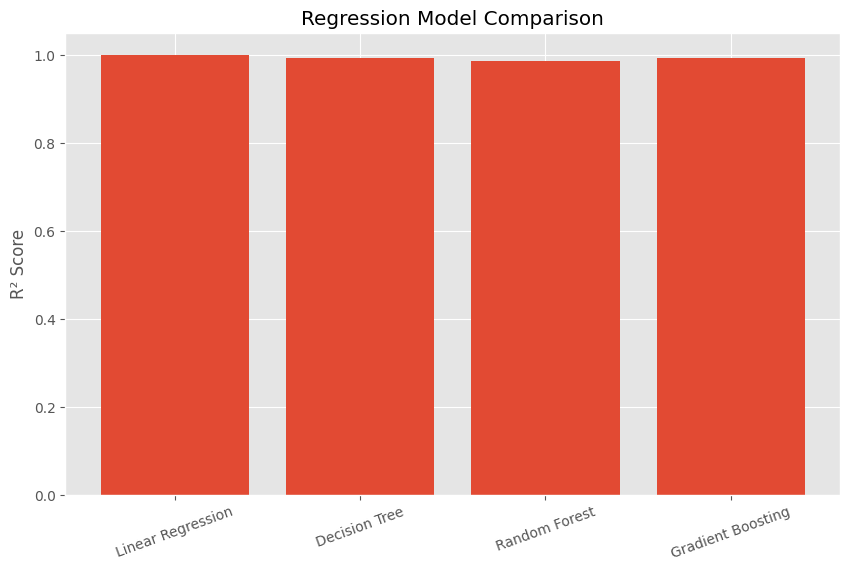

In [66]:
plt.figure(figsize=(10,6))

plt.bar(
    comparison["Model"],
    comparison["R²"]
)

plt.title("Regression Model Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

plt.show()

### 8.7 Feature Importance

Tree-based models provide estimates of feature importance, indicating the contribution of each predictor to the model.

In [67]:
# ============================================================
# Feature Importance
# ============================================================

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
107,Total funding/liabilities and equities,0.184769
27,All other liabilities,0.157534
28,Available stable funding (ASF),0.135497
112,Total regulatory capital (or balance sheet cap...,0.112084
30,Average total assets,0.109931
40,Exposure,0.093681
106,Total funding,0.035856
111,Total regulatory capital,0.025459
32,CET1 capital,0.015657
26,All other assets,0.009130


#### 8.7.1 Visualize Feature Importance

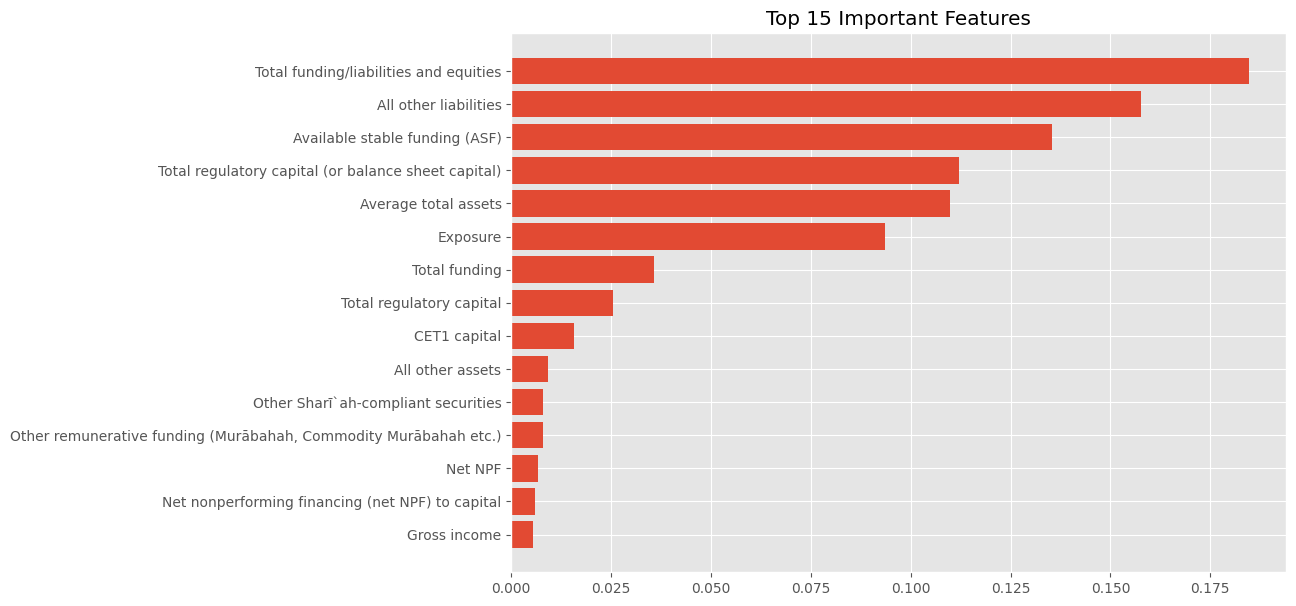

In [68]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.show()

### Interpretation

The comparison demonstrates how different regression algorithms perform on the same Islamic banking dataset. Linear Regression serves as a benchmark, while Decision Tree, Random Forest, and Gradient Boosting capture increasingly complex nonlinear relationships.

The feature importance analysis identifies the financial indicators that contribute most to predicting Total assets. These findings provide practical insights into the drivers of Islamic banking performance and support evidence-based decision making.

### 8.9 Select the Best Regression Model

For the remainder of the notebook, the model with the highest predictive performance will be selected as the reference model.

In [69]:
best_model = comparison.loc[
    comparison["R²"].idxmax(),
    "Model"
]

print(f"Best Regression Model: {best_model}")

Best Regression Model: Linear Regression


### End of Regression Analysis

At this stage, the regression component of the notebook is complete. Students have developed, evaluated, and compared multiple predictive models using the same dataset. The next stage introduces classification modeling, where the objective shifts from predicting a continuous value to assigning observations to predefined classes.

## Section 9: Classification Modeling

### 9.1 Purpose

Classification is a supervised machine learning technique used to predict categorical outcomes. Unlike regression, which estimates continuous numerical values, classification assigns observations to predefined classes.

In this notebook, the binary target variable High_Asset_Bank created in Section 6 will be used to classify Islamic banking observations into two categories:

- 1 = High Asset Bank
- 0 = Low Asset Bank

Four classification algorithms will be developed and compared to identify the most accurate model for predicting banking categories.

### 9.2 Prepare Features and Classification Target

The predictor matrix remains unchanged, while the target variable is replaced with the binary classification variable.

In [70]:
# ============================================================
# Prepare Classification Dataset
# ============================================================

target_classification = "High_Asset_Bank"

X = df_model.drop(
    columns=[
        "Country",
        "Year",
        "Quarter",
        "Year_Quarter",
        "Total assets",
        "High_Asset_Bank"
    ],
    errors="ignore"
)

y = df_model[target_classification]

print(f"Predictor Variables : {X.shape[1]}")
print(f"Observations        : {X.shape[0]}")

Predictor Variables : 119
Observations        : 227


### 9.3 Train-Test Split

The same 80:20 split is adopted for classification.

In [71]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training observations : {X_train.shape[0]}")
print(f"Testing observations  : {X_test.shape[0]}")

Training observations : 181
Testing observations  : 46


> Using stratify=y ensures that both training and testing datasets preserve the original class distribution.

### 9.4 Feature Scaling

Scaling is applied because Logistic Regression and K-Nearest Neighbors are sensitive to feature magnitudes.

In [72]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### 9.5 Logistic Regression

Logistic Regression serves as the baseline classification model.

In [73]:
# ============================================================
# Logistic Regression
# ============================================================

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 9.6 Decision Tree Classifier

In [74]:
# ============================================================
# Decision Tree Classifier
# ============================================================

dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### 9.7 Random Forest Classifier

In [75]:
# ============================================================
# Random Forest Classifier
# ============================================================

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


### 9.8 K-Nearest Neighbors (KNN)

KNN predicts the class of a new observation based on the majority class among its nearest neighbors.

In [76]:
# ============================================================
# K-Nearest Neighbors
# ============================================================

knn_classifier = KNeighborsClassifier(
    n_neighbors=5
)

knn_classifier.fit(X_train_scaled, y_train)

y_pred_knn = knn_classifier.predict(X_test_scaled)

print("KNN model trained successfully.")

KNN model trained successfully.


### 9.9 Evaluate Classification Models

Each model is evaluated using five commonly used classification metrics.

In [77]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_classifier(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }

#### 9.9.1 Evaluate All Models

In [78]:
# ============================================================
# Evaluate Models
# ============================================================

classification_results = pd.DataFrame({

    "Logistic Regression":
        evaluate_classifier(y_test, y_pred_log),

    "Decision Tree":
        evaluate_classifier(y_test, y_pred_dt),

    "Random Forest":
        evaluate_classifier(y_test, y_pred_rf),

    "KNN":
        evaluate_classifier(y_test, y_pred_knn)

}).T

classification_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.978261,1.0,0.956522,0.977778,0.978261
Decision Tree,0.978261,1.0,0.956522,0.977778,0.978261
Random Forest,1.000000,1.0,1.000000,1.000000,1.000000
KNN,0.978261,1.0,0.956522,0.977778,0.978261


### 9.10 Compare Classification Models

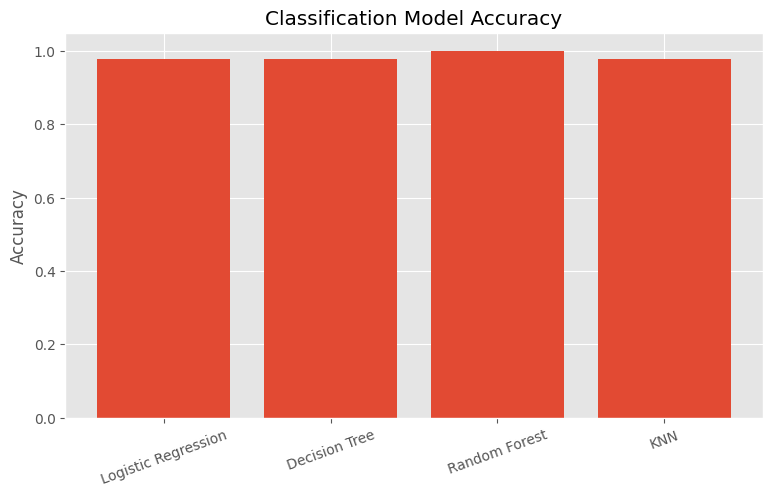

In [79]:
plt.figure(figsize=(9,5))

plt.bar(
    classification_results.index,
    classification_results["Accuracy"]
)

plt.title("Classification Model Accuracy")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

### Interpretation

The comparison demonstrates how different classification algorithms perform in identifying high-asset and low-asset banking observations. Logistic Regression provides a simple and interpretable benchmark, while Decision Tree, Random Forest, and K-Nearest Neighbors capture increasingly complex decision boundaries.

The evaluation metrics enable a comprehensive assessment of classification performance, supporting the selection of the most appropriate model for banking prediction tasks.

## Section 10: Model Evaluation and Explainability

### 10.1 Purpose

Developing machine learning models is only one stage of the predictive analytics process. Equally important is evaluating model performance, interpreting the predictions, and understanding which financial indicators contribute most to the model's decisions.

This section compares the best-performing regression and classification models, visualizes their performance, and explains the importance of individual financial indicators. These analyses provide valuable insights into the factors influencing Islamic banking performance and demonstrate how machine learning can support evidence-based decision making.

### 10.2 Best Regression Model

Display the best-performing regression model identified in Section 8.

In [80]:
# ============================================================
# Best Regression Model
# ============================================================

best_regression = comparison.sort_values(
    by="R²",
    ascending=False
).iloc[0]

print("Best Regression Model")
print(best_regression)

Best Regression Model
Model    Linear Regression
MAE            4828.468984
RMSE          12388.631128
R²                0.999944
Name: 0, dtype: object


### 10.3 Best Classification Model

Identify the classifier with the highest accuracy.

In [81]:
# ============================================================
# Best Classification Model
# ============================================================

best_classifier = classification_results[
    "Accuracy"
].idxmax()

print(f"Best Classification Model: {best_classifier}")

Best Classification Model: Random Forest


### 10.4 Confusion Matrix

The confusion matrix summarizes the classification results by comparing the predicted and actual classes.

For consistency, the Random Forest Classifier is used.

In [82]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Low","Actual High"],
    columns=["Predicted Low","Predicted High"]
)

cm_df

,Predicted Low,Predicted High
Actual Low,23,0
Actual High,0,23


#### 10.4.1 Visualize the Confusion Matrix

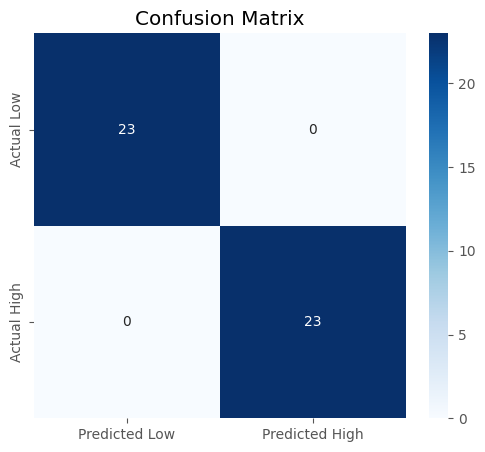

In [83]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

### 10.5 Classification Report

In [84]:
# ============================================================
# Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        23

    accuracy                           1.00        46
   macro avg       1.00      1.00      1.00        46
weighted avg       1.00      1.00      1.00        46



### 10.6 ROC Curve

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off between the true positive rate and false positive rate across different classification thresholds.

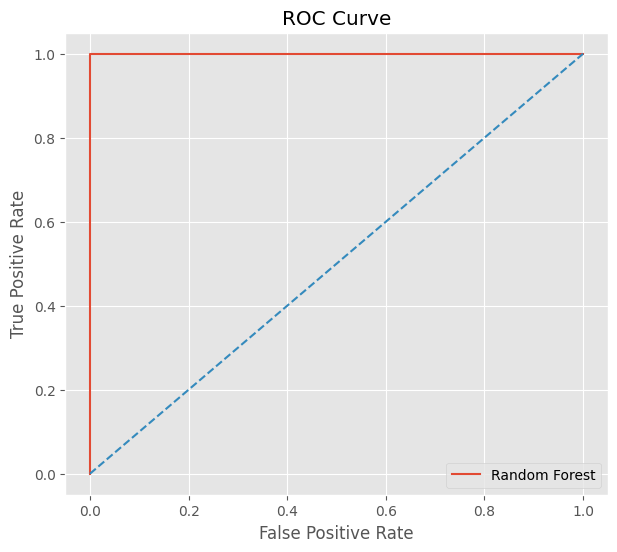

In [85]:
# ============================================================
# ROC Curve
# ============================================================

probabilities = rf_classifier.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### 10.7 Feature Importance

The Random Forest model estimates the contribution of each financial indicator to the prediction of Total assets.

In [86]:
# ============================================================
# Top 20 Features
# ============================================================

top20 = (
    feature_importance
    .head(20)
)

display(top20)

,Feature,Importance
107,Total funding/liabilities and equities,0.184769
27,All other liabilities,0.157534
28,Available stable funding (ASF),0.135497
112,Total regulatory capital (or balance sheet cap...,0.112084
30,Average total assets,0.109931
40,Exposure,0.093681
106,Total funding,0.035856
111,Total regulatory capital,0.025459
32,CET1 capital,0.015657
26,All other assets,0.009130


#### 10.7.1 Visualize Feature Importance

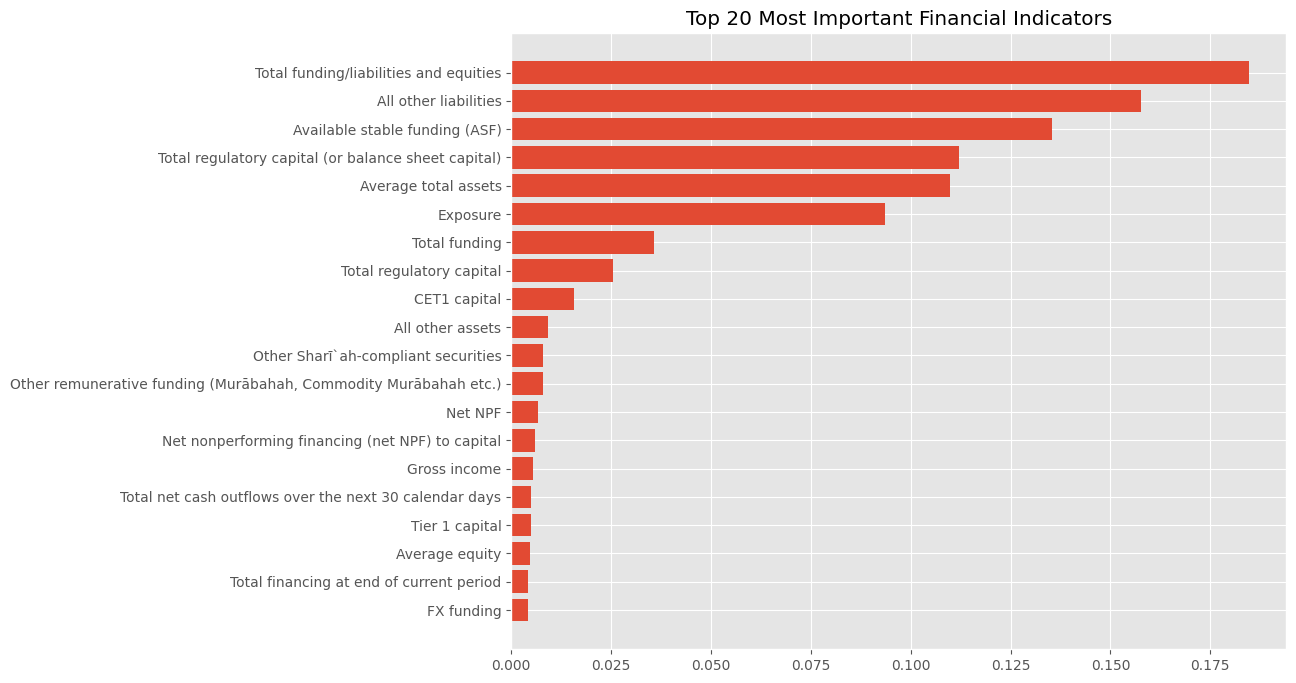

In [87]:
plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Financial Indicators")

plt.show()

### Interpretation of Results

The feature importance analysis identifies the financial indicators that contribute most strongly to predicting Total assets. Variables receiving higher importance scores have a greater influence on model predictions and may therefore represent key drivers of Islamic banking performance.

From a practical perspective, these findings can assist:

- Islamic banks in identifying key financial performance drivers.
- Regulators in monitoring sector stability.
- Researchers in selecting influential variables for future empirical studies.
- Policymakers in evaluating the financial development of Islamic banking systems.

### 10.9 Summary of Machine Learning Models

| Task           | Best Model             | Primary Evaluation Metric                |
| -------------- | ---------------------- | ---------------------------------------- |
| Regression     | Highest R² Model       | R², RMSE, MAE                            |
| Classification | Highest Accuracy Model | Accuracy, Precision, Recall, F1, ROC-AUC |


### 10.10 Business Insights and Practical Applications

Machine learning extends beyond predictive accuracy by providing practical insights that support strategic and operational decision-making. The regression and classification models developed in this notebook demonstrate how financial indicators can be used to understand the performance and growth of Islamic banking institutions.

The feature importance analysis indicates that certain financial indicators contribute more significantly to predicting Total Assets than others. These variables may therefore be regarded as key performance drivers within the Islamic banking industry.

The results of this notebook have several practical implications.

For Islamic Banks
>- Identify the financial indicators that most strongly influence asset growth.
>- Support strategic planning through predictive analytics.
>- Improve portfolio monitoring and financial performance assessment.
>- Strengthen risk management by identifying emerging trends.

For Regulators
>- Monitor the financial health of the Islamic banking sector.
>- Detect unusual movements in key banking indicators.
>- Support macroprudential supervision using predictive models.
>- Improve evidence-based regulatory decision making.

For Policymakers
>- Evaluate the development of Islamic banking across countries.
>- Monitor financial inclusion and sectoral growth.
>- Assess the effectiveness of Islamic finance policies.

For Researchers
>- Identify influential variables for future empirical studies.
>- Compare machine learning methods with conventional econometric models.
>- Extend the analysis using alternative datasets and advanced algorithms.

### 10.11 Practical Limitations

Although the developed models achieved satisfactory predictive performance, several limitations should be acknowledged.

>- The analysis is based on historical financial indicators and therefore cannot capture future structural changes in the banking industry.
>- Several financial indicators required imputation because of incomplete reporting across countries.
>- The models were developed using structured financial variables only and do not incorporate macroeconomic, political, or behavioural factors.
>- Model performance may vary when applied to other countries or reporting periods.
>- Machine learning identifies predictive relationships but does not establish causal relationships.

Recognizing these limitations is an essential part of responsible data-driven decision making.

### 10.12 Future Improvements

This notebook introduces the fundamental workflow of predictive analytics for Islamic banking. Future studies may extend this work by incorporating more advanced techniques.

Potential extensions include:

>- XGBoost Regression and Classification
>- LightGBM
>- CatBoost
>- Support Vector Machines
>- Artificial Neural Networks
>- Deep Learning
>- Time-Series Forecasting
>- Explainable Artificial Intelligence (SHAP and LIME)
>- Hyperparameter Optimization using Grid Search or Random Search
>- Cross-Validation for robust model evaluation

These approaches may further improve predictive accuracy and model interpretability.

### 10.13 Predicting New Observations Using the Best Model
Purpose

The final objective of any machine learning model is to generate predictions for unseen observations. After training and evaluating the regression and classification models, this section demonstrates how the best-performing models can be used to predict financial outcomes for new Islamic banking observations.

For demonstration purposes, several observations from the testing dataset are selected. Since these observations were not used during model training, they provide an appropriate basis for evaluating predictive performance.

#### 10.13.1 Display Sample Test Observations

In [89]:
# ============================================================
# Display Sample Test Observations
# ============================================================

sample_data = X_test.head(5)

sample_data

,"(a) agriculture, forestry, hunting and fishing",(b) mining and quarrying,(c) manufacturing,"(d) electricity, gas, steam and air-conditioning supply",(e) water supply; sewerage and waste management,(f)construction,(g) wholesale and retail trade; repair of motor vehicles and motorcycles,(h) transportation and storage,(i),(i)accommodation and food service activities,...,Total net cash outflows over the next 30 calendar days,Total off-balance sheet items to total assets,Total regulatory capital,Total regulatory capital (or balance sheet capital),Total returns,Total revenues,Value of Sharī`ah-compliant financing,Value of Sukūk holdings to capital,Value of gross NPF,Wakālah
187,1182.81,1381.91,39201.68,4083.01,294.666667,8364.80,20962.36,7921.02,14.476667,544.46,...,165362.63,11.32,76564.07,175387.565,15526.690,21747.12,336501.54,18.26,3806.59,0.00
117,16723.86,3189.77,31206.82,6120.81,1151.430000,43284.09,35209.05,12144.22,19.416667,2370.50,...,144433.09,31.22,82211.44,175387.565,25527.795,39392.69,714605.63,201.07,9567.29,275.58
27,30671.77,1587.34,1037693.76,37027.35,609.970000,84737.41,960436.01,39250.23,0.000000,23297.45,...,189201.26,17.44,243756.16,243756.160,120354.270,133526.43,2640776.23,21.59,118069.63,1647.91
65,12784.08,4020.26,18121.20,6329.17,317.250000,18115.35,29056.69,7683.86,229.840000,3369.85,...,165362.63,-2.22,47774.33,175387.565,6685.480,12713.27,248181.01,128.90,8022.98,4.22
107,15946.74,3061.07,25478.42,2872.07,0.000000,35289.62,24730.59,12698.86,10.466667,2373.88,...,102156.71,34.20,64061.27,175387.565,25527.795,21310.37,581904.50,192.13,9735.42,0.00


#### 10.13.2 Predict Total Assets (Regression)

Using the best-performing regression model, predict the Total Assets for the selected observations.

In [90]:
# ============================================================
# Regression Prediction
# ============================================================

predicted_assets = rf_model.predict(sample_data)

prediction_results = pd.DataFrame({

    "Actual Total Assets": y_test.head(5).values,

    "Predicted Total Assets": predicted_assets

})

prediction_results["Prediction Error"] = (
    prediction_results["Actual Total Assets"]
    - prediction_results["Predicted Total Assets"]
)

prediction_results

,Actual Total Assets,Predicted Total Assets,Prediction Error
0,0,5.017435e+05,-5.017435e+05
1,1,9.344688e+05,-9.344678e+05
2,1,3.348121e+06,-3.348120e+06
3,0,3.945208e+05,-3.945208e+05
4,0,7.847227e+05,-7.847227e+05


#### 10.13.3 Predict Banking Category (Classification)

The same observations are now classified using the best-performing classification model.

In [91]:
# ============================================================
# Classification Prediction
# ============================================================

predicted_class = rf_classifier.predict(sample_data)

classification_results = pd.DataFrame({

    "Actual Class": y_test.head(5).values,

    "Predicted Class": predicted_class

})

classification_results

,Actual Class,Predicted Class
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0


#### 10.13.4 Prediction Probability

In addition to the predicted class, machine learning models can estimate the probability associated with each prediction.

In [92]:
# ============================================================
# Prediction Probability
# ============================================================

probabilities = rf_classifier.predict_proba(sample_data)

probability_df = pd.DataFrame(

    probabilities,

    columns=[
        "Probability (Low Asset)",
        "Probability (High Asset)"
    ]

)

probability_df

,Probability (Low Asset),Probability (High Asset)
0,1.000,0.000
1,0.035,0.965
2,0.005,0.995
3,1.000,0.000
4,0.985,0.015


### Interpretation

The prediction results demonstrate the practical application of machine learning in Islamic banking. Rather than simply evaluating model performance through statistical metrics, the trained models can now generate predictions for previously unseen observations.

The regression model estimates future values of Total Assets, while the classification model determines whether an observation belongs to the High Asset Bank or Low Asset Bank category. The associated prediction probabilities provide additional insight into the confidence of each classification.

These examples illustrate how predictive analytics can support financial decision-making by enabling banks, regulators, and researchers to estimate future outcomes using historical financial indicators.

### 10.14 Country-wise Prediction and Decision Support
Purpose

The ultimate objective of predictive analytics is to support informed decision-making. After training and evaluating the machine learning models, predictions can be generated for individual countries and reporting periods. This section demonstrates how the best-performing regression and classification models can be applied to produce country-specific predictions and compare them with actual reported values.

This approach enables students to understand how machine learning models can be used in practical Islamic banking applications, including country performance analysis, regulatory monitoring, and financial forecasting.

### 10.14.1 Preserve Country Information

Before creating the feature matrix, the country and reporting period information should be retained for reporting purposes.

Note: This code should be executed before removing the identifier variables in Section 7.

In [93]:
# Preserve the observation information for reference

observation_info = df_model[
    ["Country", "Year_Quarter"]
].copy()

#### 10.14.2 Preserve Observation Information After Train-Test Split

In [94]:
# ============================================================
# Preserve Country Information
# ============================================================

info_train = observation_info.loc[X_train.index]

info_test = observation_info.loc[X_test.index]

#### 10.14.3 Country-wise Regression Predictions

The best-performing regression model is now used to predict Total Assets for the testing observations.

In [95]:
# ============================================================
# Country-wise Regression Predictions
# ============================================================

predicted_assets = rf_model.predict(X_test)

country_predictions = pd.DataFrame({

    "Country": info_test["Country"].values,

    "Year_Quarter": info_test["Year_Quarter"].values,

    "Actual Total Assets": y_test.values,

    "Predicted Total Assets": predicted_assets

})

country_predictions["Prediction Error"] = (
    country_predictions["Actual Total Assets"]
    - country_predictions["Predicted Total Assets"]
).round(2)

country_predictions.head(10)

,Country,Year_Quarter,Actual Total Assets,Predicted Total Assets,Prediction Error
0,Saudi Arabia,2014-Q4,0,5.017435e+05,-501743.52
1,Malaysia,2021-Q4,1,9.344688e+05,-934467.79
2,Bangladesh,2020-Q3,1,3.348121e+06,-3348120.16
3,Indonesia,2021-Q1,0,3.945208e+05,-394520.79
4,Malaysia,2019-Q2,0,7.847227e+05,-784722.67
5,Saudi Arabia,2018-Q2,0,6.196861e+05,-619686.07
6,Bangladesh,2016-Q3,1,2.017072e+06,-2017070.93
7,Pakistan,2022-Q4,1,4.041200e+06,-4041199.15
8,Indonesia,2019-Q1,0,3.182342e+05,-318234.16
9,Malaysia,2023-Q3,1,1.061119e+06,-1061117.52


#### 10.14.4 Country-wise Classification Predictions

The same observations are classified using the best-performing classification model.

In [96]:
# ============================================================
# Country-wise Classification Predictions
# ============================================================

predicted_class = rf_classifier.predict(X_test)

classification_predictions = pd.DataFrame({

    "Country": info_test["Country"].values,

    "Year_Quarter": info_test["Year_Quarter"].values,

    "Actual Class": y_test.values,

    "Predicted Class": predicted_class

})

classification_predictions.head(10)

,Country,Year_Quarter,Actual Class,Predicted Class
0,Saudi Arabia,2014-Q4,0,0
1,Malaysia,2021-Q4,1,1
2,Bangladesh,2020-Q3,1,1
3,Indonesia,2021-Q1,0,0
4,Malaysia,2019-Q2,0,0
5,Saudi Arabia,2018-Q2,0,0
6,Bangladesh,2016-Q3,1,1
7,Pakistan,2022-Q4,1,1
8,Indonesia,2019-Q1,0,0
9,Malaysia,2023-Q3,1,1


#### 10.14.5 Search Predictions for a Specific Country

Students can retrieve prediction results for any country included in the dataset.

In [97]:
country_predictions[
    country_predictions["Country"] == "Pakistan"
]

,Country,Year_Quarter,Actual Total Assets,Predicted Total Assets,Prediction Error
7,Pakistan,2022-Q4,1,4.041200e+06,-4041199.15
10,Pakistan,2017-Q1,1,1.167409e+06,-1167408.13
14,Pakistan,2015-Q1,0,7.936565e+05,-793656.50
22,Pakistan,2023-Q3,1,5.879268e+06,-5879267.41
28,Pakistan,2022-Q2,1,3.705759e+06,-3705757.57
33,Pakistan,2018-Q4,1,1.580274e+06,-1580272.81
38,Pakistan,2016-Q2,1,1.061502e+06,-1061500.78
41,Pakistan,2019-Q1,1,1.656499e+06,-1656497.82


In [98]:
country_predictions[
    country_predictions["Country"] == "Malaysia"
]

,Country,Year_Quarter,Actual Total Assets,Predicted Total Assets,Prediction Error
1,Malaysia,2021-Q4,1,9.344688e+05,-934467.79
4,Malaysia,2019-Q2,0,7.847227e+05,-784722.67
9,Malaysia,2023-Q3,1,1.061119e+06,-1061117.52
12,Malaysia,2014-Q2,0,4.405378e+05,-440537.84
20,Malaysia,2020-Q1,0,8.183518e+05,-818351.78
25,Malaysia,2022-Q3,1,1.011682e+06,-1011680.81
30,Malaysia,2023-Q2,1,1.054164e+06,-1054163.16
31,Malaysia,2016-Q3,0,5.523348e+05,-552334.82
37,Malaysia,2020-Q4,1,8.779680e+05,-877966.98
39,Malaysia,2014-Q3,0,4.501688e+05,-450168.82


In [99]:
country_predictions[
    country_predictions["Country"] == "Indonesia"
]

,Country,Year_Quarter,Actual Total Assets,Predicted Total Assets,Prediction Error
3,Indonesia,2021-Q1,0,394520.78940,-394520.79
8,Indonesia,2019-Q1,0,318234.16495,-318234.16
16,Indonesia,2023-Q1,0,530503.29415,-530503.29
18,Indonesia,2017-Q2,0,271597.07365,-271597.07
21,Indonesia,2019-Q3,0,329420.97960,-329420.98
35,Indonesia,2018-Q4,0,316917.19060,-316917.19
42,Indonesia,2014-Q1,0,187906.57995,-187906.58
45,Indonesia,2014-Q2,0,191329.45875,-191329.46


#### 10.14.6 Country Performance Summary

The following summary compares the average prediction error across countries.

In [100]:
# ============================================================
# Country Performance Summary
# ============================================================

country_summary = (
    country_predictions
    .groupby("Country")
    .agg({
        "Prediction Error":"mean",
        "Actual Total Assets":"mean",
        "Predicted Total Assets":"mean"
    })
    .round(2)
)

country_summary

,Prediction Error,Actual Total Assets,Predicted Total Assets
Country,,,
Bangladesh,-3191498.38,1.00,3191499.38
Indonesia,-317553.69,0.00,317553.69
Malaysia,-798551.22,0.50,798551.72
Pakistan,-2485695.02,0.88,2485695.90
Saudi Arabia,-765327.93,0.25,765328.18
